<a href="https://colab.research.google.com/github/Prabhjot-Singh1/Concurrent-Programming-Lab/blob/main/CP_FINAL_PRACTICAL_EXAM/CP_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numba -q

In [2]:
import numpy as np
from numba import cuda
import time
import matplotlib.pyplot as plt

In [3]:
N = 2048  # matrix size

# Create large random matrix
A = np.random.rand(N, N).astype(np.float32)
B = np.random.rand(N, N).astype(np.float32)

print(f"Matrix size: {N} x {N}")
print(f"Each matrix size in MB: {A.nbytes / 1024**2:.1f} MB")

Matrix size: 2048 x 2048
Each matrix size in MB: 16.0 MB


In [4]:
# ── Kernel: Matrix Addition ─────────────────────────────────────
# We test the SAME kernel with 3 different block sizes
# to see which gives best performance

@cuda.jit
def matrix_add(A, B, C, N):
    row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
    if row < N and col < N:
        C[row, col] = A[row, col] + B[row, col]

In [5]:
# Copy matrices to GPU once
d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.device_array((N, N), dtype=np.float32)

# 3 block sizes to test
block_sizes = [8, 16, 32]
results = []

for bs in block_sizes:
    # Calculate grid size
    grid_x = (N + bs - 1) // bs
    grid_y = (N + bs - 1) // bs

    threads_per_block = (bs, bs)
    blocks_per_grid   = (grid_x, grid_y)

    # Warmup run
    matrix_add[blocks_per_grid, threads_per_block](d_A, d_B, d_C, N)
    cuda.synchronize()

    # Timed run
    start = time.time()
    for _ in range(10):  # run 10 times for stable measurement
        matrix_add[blocks_per_grid, threads_per_block](d_A, d_B, d_C, N)
    cuda.synchronize()
    elapsed = (time.time() - start) / 10  # average time

    # Calculate metrics
    total_threads    = bs * bs
    total_operations = N * N
    throughput_gb    = (3 * A.nbytes) / elapsed / 1e9  # read A, read B, write C
    occupancy_est    = min(total_threads / 1024, 1.0) * 100  # max 1024 threads/block

    results.append({
        'block_size'   : bs,
        'threads/block': total_threads,
        'blocks'       : grid_x * grid_y,
        'time_ms'      : elapsed * 1000,
        'throughput_gb': throughput_gb,
        'occupancy_%'  : occupancy_est
    })

    print(f"\nBlock size {bs}x{bs} ({total_threads} threads/block):")
    print(f"  Grid size        : {grid_x} x {grid_y} = {grid_x*grid_y:,} blocks")
    print(f"  Avg time         : {elapsed*1000:.2f} ms")
    print(f"  Memory throughput: {throughput_gb:.2f} GB/s")
    print(f"  Occupancy (est.) : {occupancy_est:.1f}%")


Block size 8x8 (64 threads/block):
  Grid size        : 256 x 256 = 65,536 blocks
  Avg time         : 0.24 ms
  Memory throughput: 211.74 GB/s
  Occupancy (est.) : 6.2%

Block size 16x16 (256 threads/block):
  Grid size        : 128 x 128 = 16,384 blocks
  Avg time         : 0.29 ms
  Memory throughput: 171.53 GB/s
  Occupancy (est.) : 25.0%

Block size 32x32 (1024 threads/block):
  Grid size        : 64 x 64 = 4,096 blocks
  Avg time         : 0.40 ms
  Memory throughput: 125.02 GB/s
  Occupancy (est.) : 100.0%


In [6]:
# Find best block size
best = min(results, key=lambda x: x['time_ms'])
print(f"\n✅ Best block size: {best['block_size']}x{best['block_size']}")
print(f"   Fastest time   : {best['time_ms']:.2f} ms")
print(f"   Throughput     : {best['throughput_gb']:.2f} GB/s")

# Verify correctness
h_C = d_C.copy_to_host()
expected = A + B
print(f"\nResult correct: {np.allclose(h_C, expected, atol=1e-5)}")


✅ Best block size: 8x8
   Fastest time   : 0.24 ms
   Throughput     : 211.74 GB/s

Result correct: True


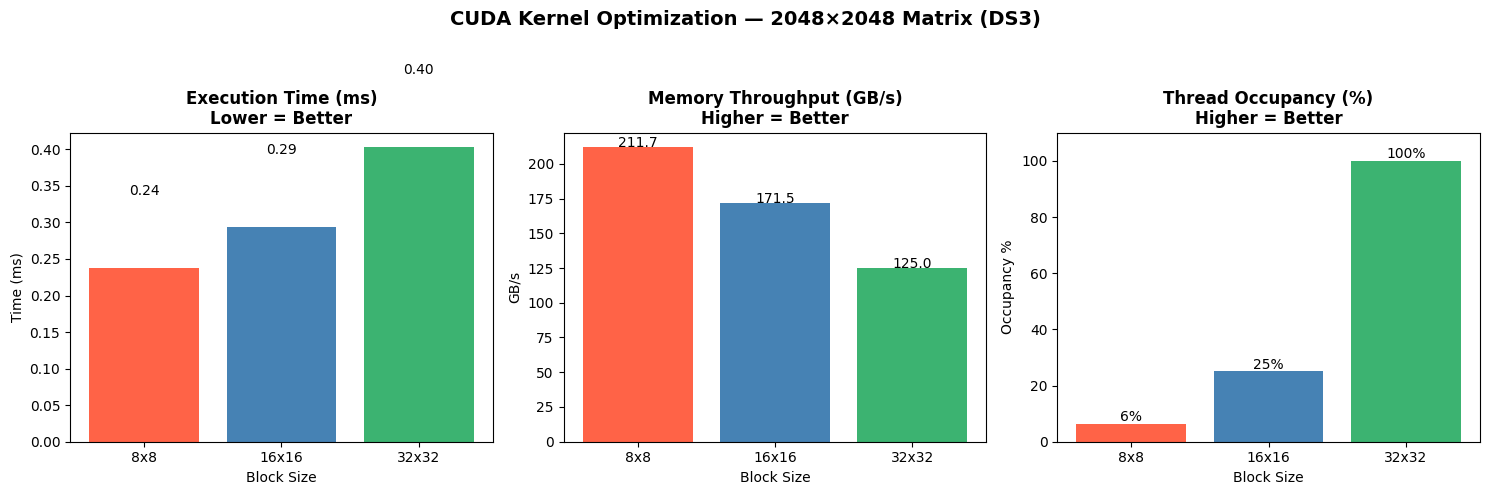

In [7]:
labels     = [f"{r['block_size']}x{r['block_size']}" for r in results]
times      = [r['time_ms']       for r in results]
throughputs= [r['throughput_gb'] for r in results]
occupancies= [r['occupancy_%']   for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Execution Time (lower = better)
bars = axes[0].bar(labels, times, color=['tomato','steelblue','mediumseagreen'])
axes[0].set_title("Execution Time (ms)\nLower = Better", fontweight='bold')
axes[0].set_xlabel("Block Size")
axes[0].set_ylabel("Time (ms)")
for bar, val in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1, f"{val:.2f}", ha='center')

# Plot 2: Memory Throughput (higher = better)
bars = axes[1].bar(labels, throughputs, color=['tomato','steelblue','mediumseagreen'])
axes[1].set_title("Memory Throughput (GB/s)\nHigher = Better", fontweight='bold')
axes[1].set_xlabel("Block Size")
axes[1].set_ylabel("GB/s")
for bar, val in zip(bars, throughputs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1, f"{val:.1f}", ha='center')

# Plot 3: Occupancy (higher = better)
bars = axes[2].bar(labels, occupancies, color=['tomato','steelblue','mediumseagreen'])
axes[2].set_title("Thread Occupancy (%)\nHigher = Better", fontweight='bold')
axes[2].set_xlabel("Block Size")
axes[2].set_ylabel("Occupancy %")
axes[2].set_ylim(0, 110)
for bar, val in zip(bars, occupancies):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f"{val:.0f}%", ha='center')

plt.suptitle("CUDA Kernel Optimization — 2048×2048 Matrix (DS3)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()